In [162]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd


In [164]:
d1 = '/home/u0890475/Downloads/amr4_curv_combtest/plt73800_curvature.csv'
df = pd.read_csv(d1)

In [166]:
df['c'] = 1- df['Y(H2)']/ 0.012181

In [168]:
df.columns

Index(['x_grid', 'y_grid', 'z_grid', 'T', 'Q', 'P', 'rho', 'cp', 'Y(H2)',
       'lambda', 'k', 'Sd', 'gradT', 'flx', 'c'],
      dtype='object')

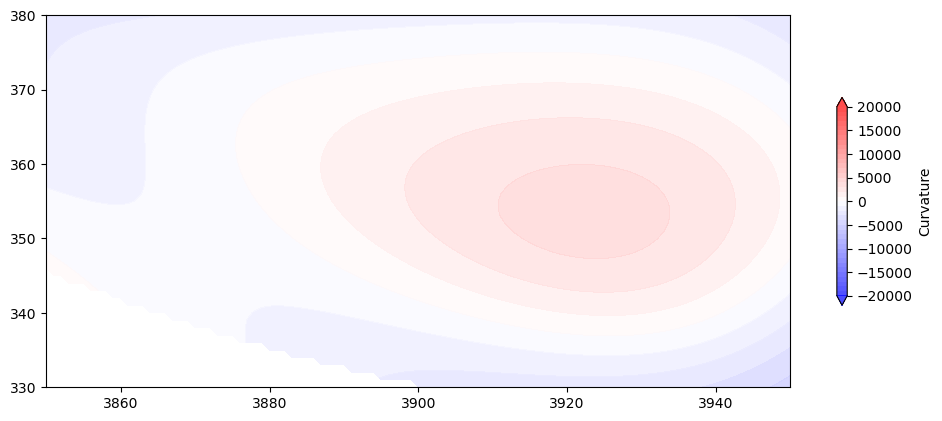

In [180]:
df2 = df[(df['x_grid']>=3850) & (df['x_grid']<=3950) &(df['y_grid']>=330) &(df['y_grid']<=380) &(df['z_grid']==1)]
divu_grid=df2.pivot_table(
    index='y_grid',
    columns='x_grid',
    values='k',
    aggfunc='median',
)
levels=np.linspace(-20000,20000,41,)
vmin=-20000
vmax=20000
X=divu_grid.columns.values
Y=divu_grid.index.values
Z=divu_grid.values
fig,ax = plt.subplots(figsize=(12,9))
ax.set_aspect('equal')
cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 ,extend='both')
cbar =plt.colorbar(cf,shrink=0.3,ax=ax,label='Curvature')

/tmp/ipykernel_173383/3441088445.py:22: UserWarning: Adding colorbar to a different Figure <Figure size 1200x900 with 2 Axes> than <Figure size 2400x600 with 3 Axes> which fig.colorbar is called on.
  cbar =plt.colorbar(cf,shrink=0.5,ax=ax[0],label='Progress Variable c')


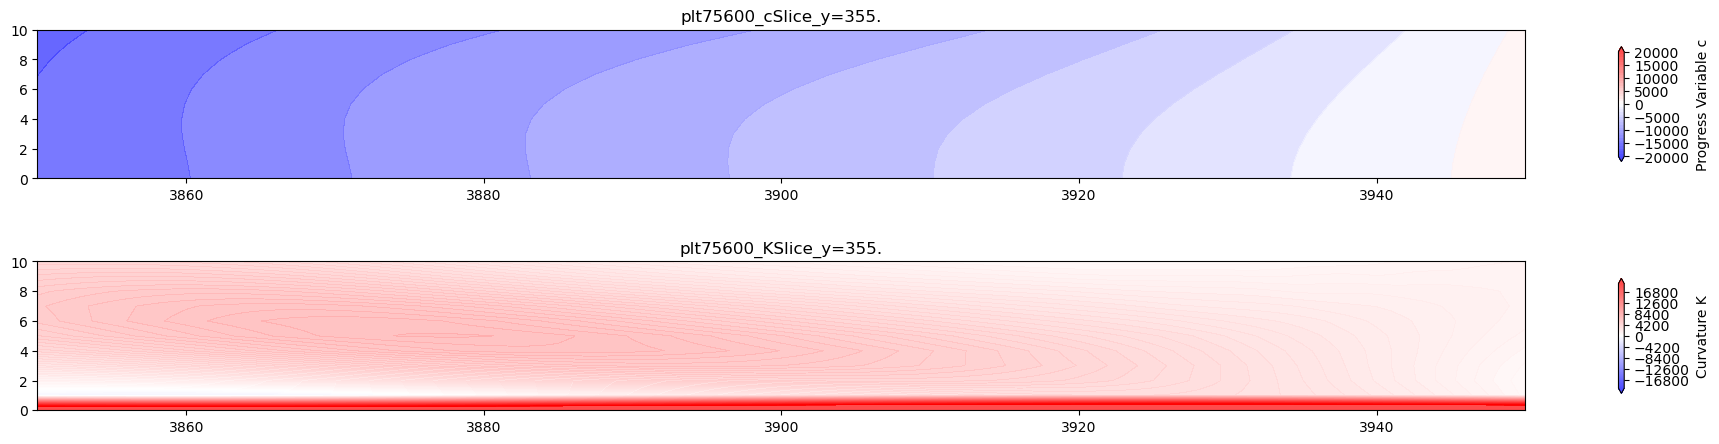

In [182]:
yslice = 355
xleft = 3850
xright= 3950
df_slice = df[(df['y_grid']==yslice ) & (df['z_grid']<=10)  & (df['x_grid']>=xleft) & (df['x_grid']<=xright)  ]
slicec_grid=df_slice.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='c',
    aggfunc='median',
)

vmin=0
vmax=1
levels1=np.linspace(0,1,21,)
X=slicec_grid.columns.values
Y=slicec_grid.index.values
Zc=slicec_grid.values

fig,ax = plt.subplots(2,1,figsize=(24,6))
ax[0].set_aspect('equal')
ax[0].set_title(f'plt75600_cSlice_y={yslice}.')
cbar =plt.colorbar(cf,shrink=0.5,ax=ax[0],label='Progress Variable c')
vkmin=-20000
vkmax= 20000
levels2=np.linspace(vkmin,vkmax,201)
cf=ax[0].contourf(X,Y,Zc,levels=levels1,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7,extend='both' )



slicek_grid=df_slice.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='k',
    aggfunc='median',
)
X=slicek_grid.columns.values
Y=slicek_grid.index.values
Zk=slicek_grid.values

cf1=ax[1].contourf(X,Y,Zk,levels=levels2,cmap='bwr',vmin=vkmin,vmax=vkmax, alpha=0.7,extend= 'both' )
ax[1].set_aspect('equal')
ax[1].set_title(f'plt75600_KSlice_y={yslice}.')

cbar2 =plt.colorbar(cf1,shrink=0.5,ax=ax[1],label='Curvature K')


fig.subplots_adjust(hspace=0.007)

#plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75600_c_slice_y={yslice}.png',dpi=300)

In [88]:
print(type(X), X.dtype)
print(type(Y), Y.dtype)
print(type(Zc), Zc.dtype)

print(X.shape)
print(Y.shape)
print(Zc.shape)

<class 'numpy.ndarray'> object
<class 'numpy.ndarray'> int64
<class 'numpy.ndarray'> float64
(202,)
(11,)
(11, 101)


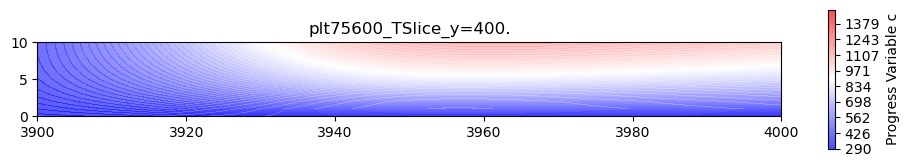

In [52]:
df_sliceT = df[(df['y_grid']==yslice ) & (df['z_grid']<=10)  & (df['x_grid']>=xleft) & (df['x_grid']<=xright)  ]
Tslice_grid=df_sliceT.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='T',
    aggfunc='median',
)

vmin=290
vmax=1500
levels=np.linspace(vmin,vmax,81,)
X=Tslice_grid.columns.values
Y=Tslice_grid.index.values
Z=Tslice_grid.values
fig,ax = plt.subplots(figsize=(12,9))
ax.set_aspect('equal')
ax.set_title(f'plt75600_TSlice_y={yslice}.')

cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
cbar =plt.colorbar(cf,shrink=0.2,ax=ax,label='Progress Variable c')
plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75600_T_slice_y={yslice}.png',dpi=300)

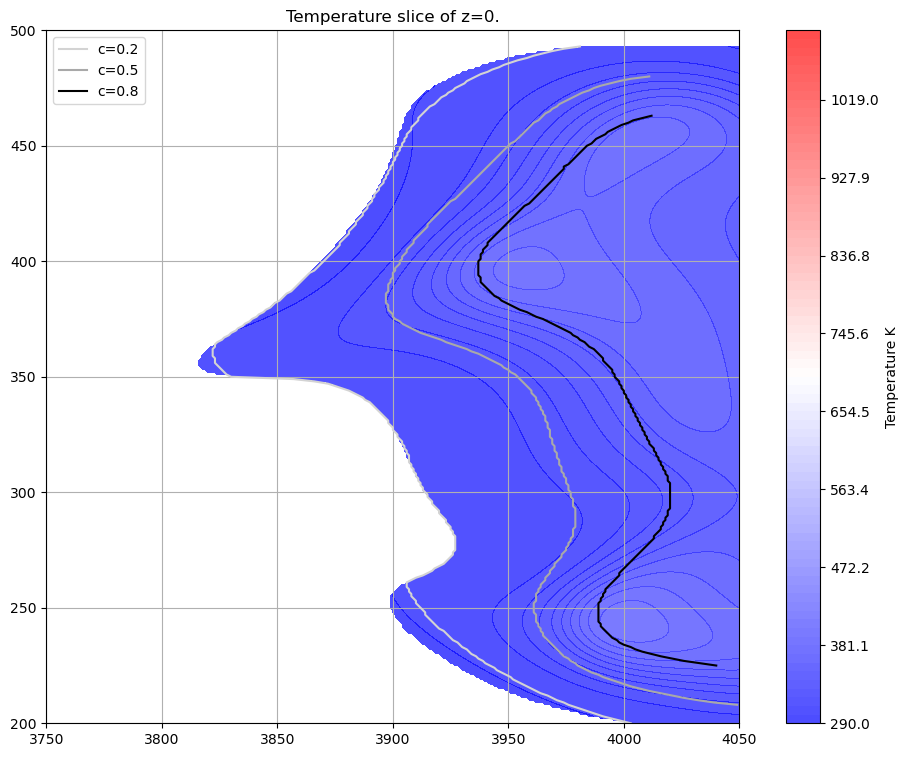

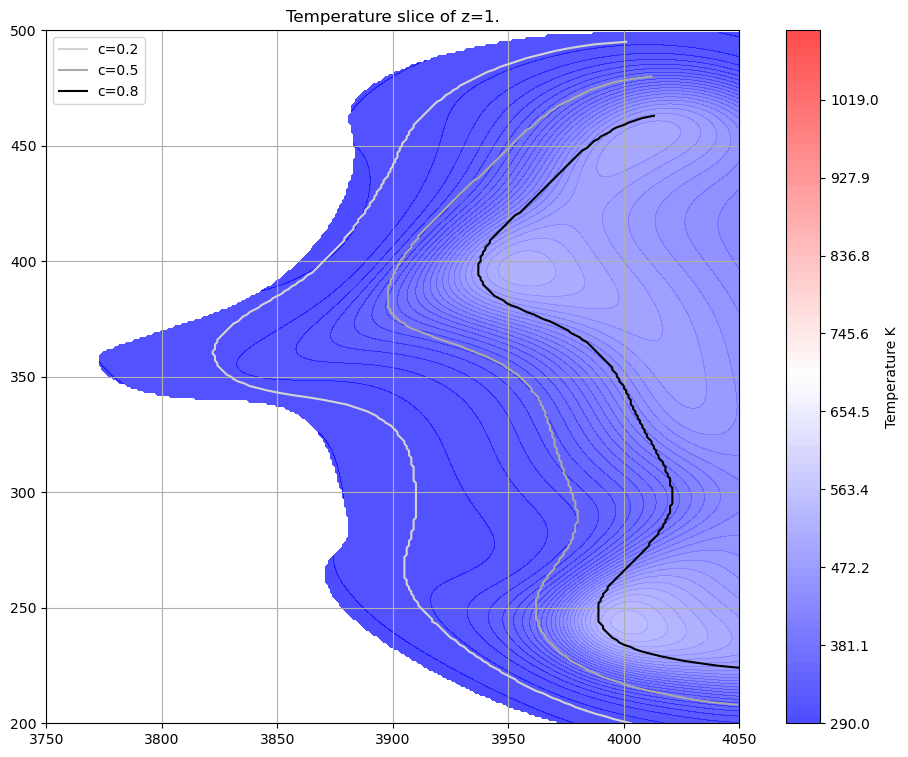

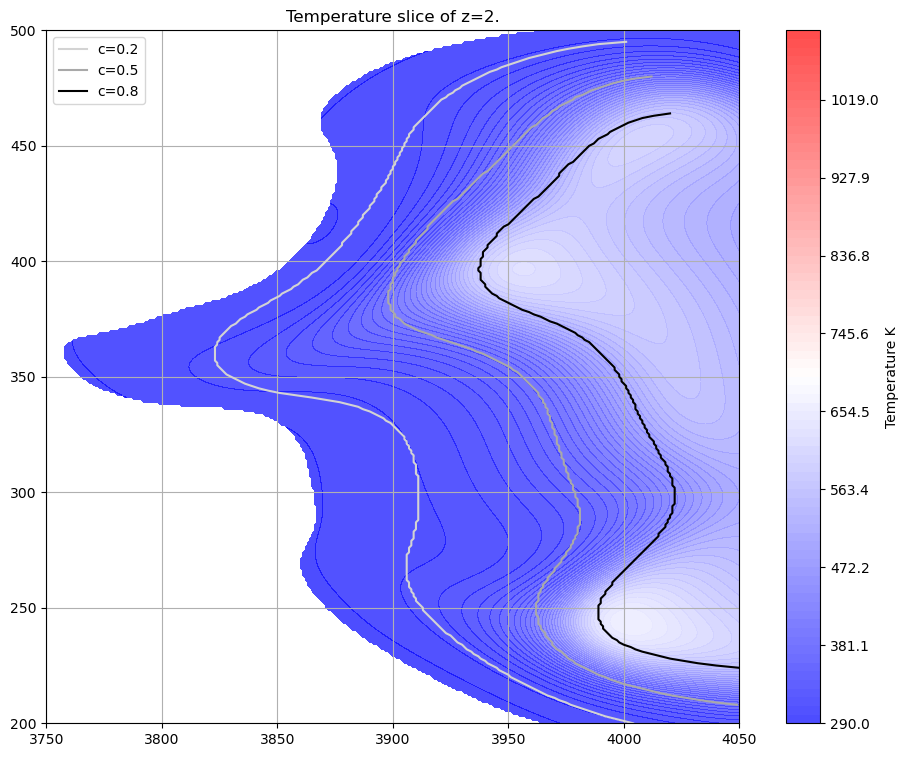

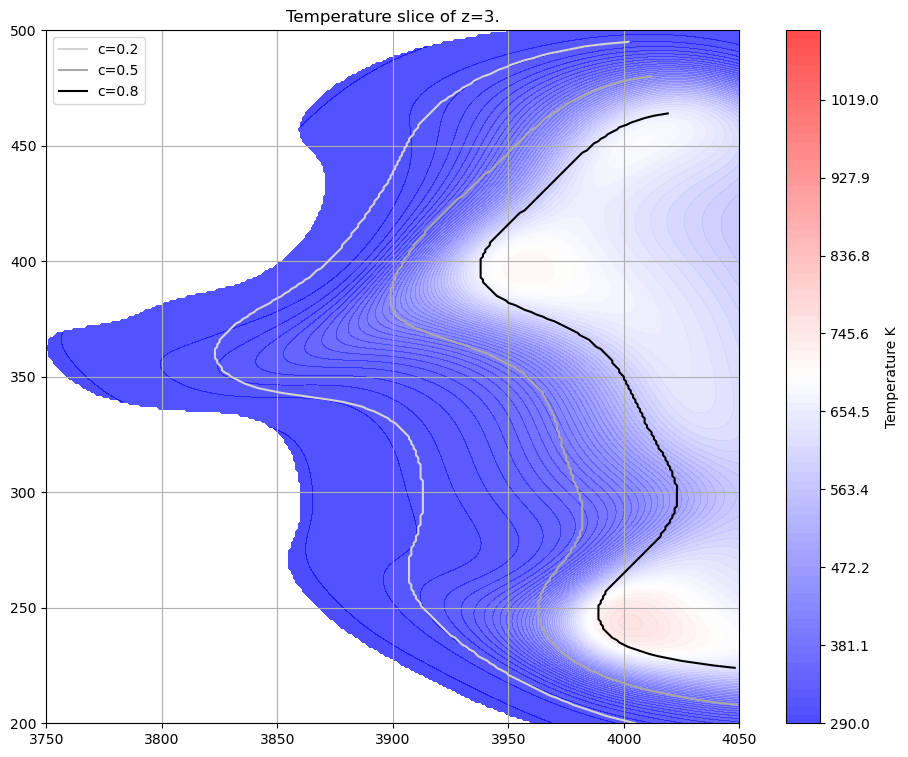

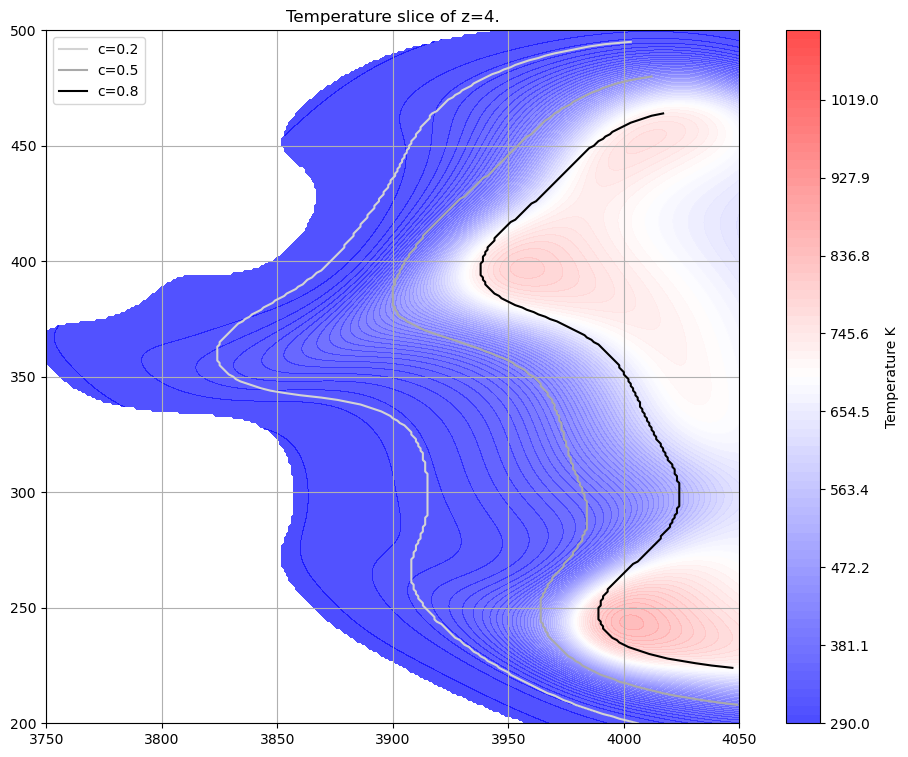

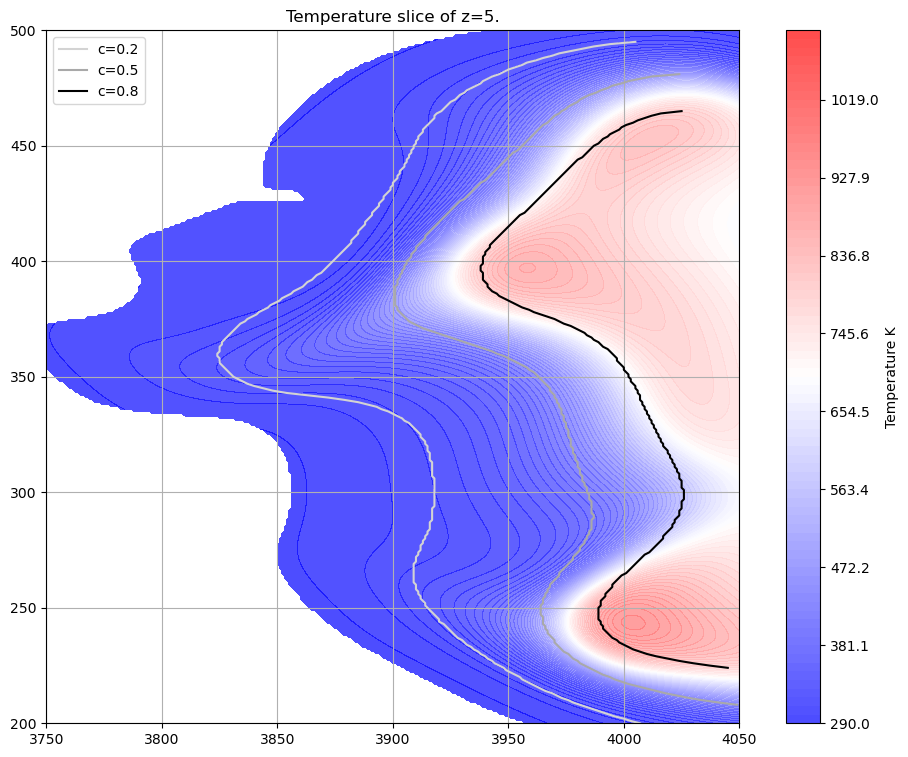

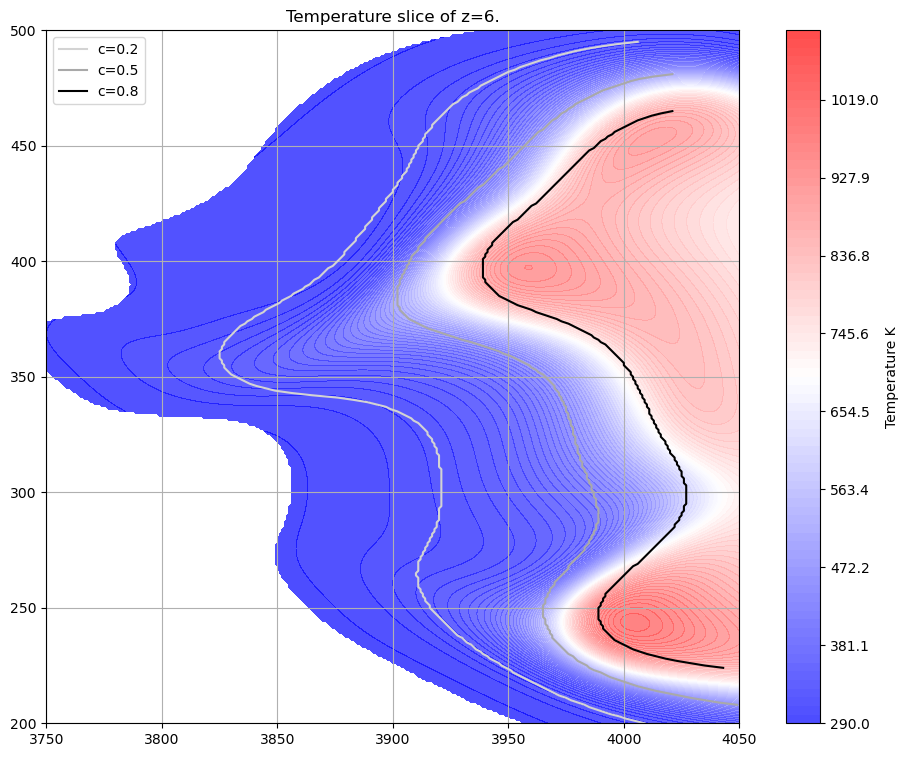

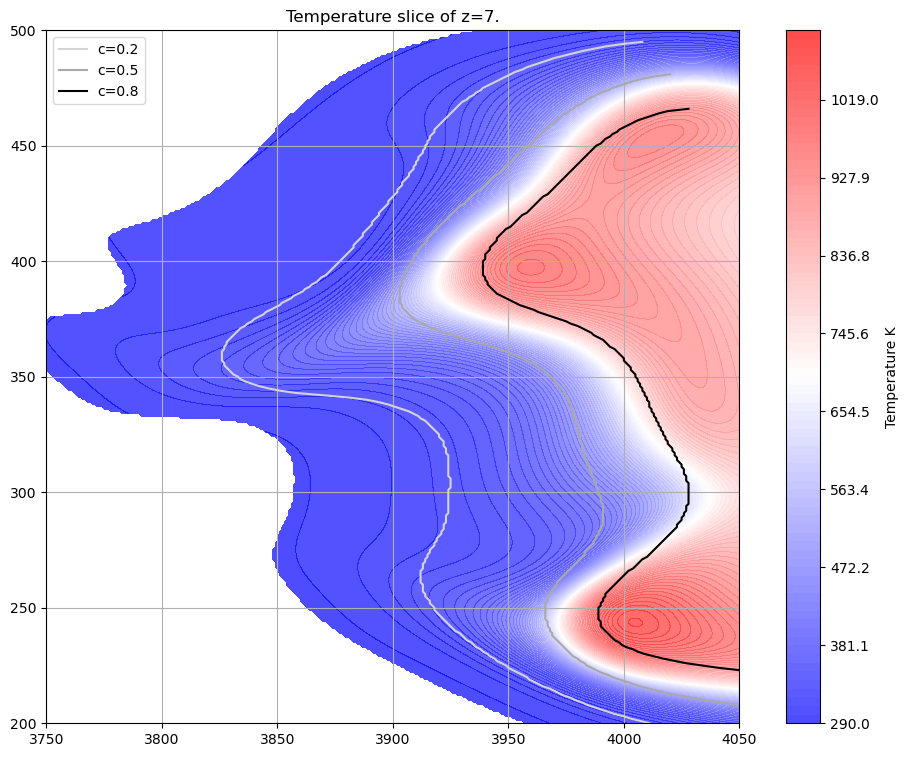

In [54]:
for i in range(0,8):
    df_s2= df[(df['z_grid']==i) & (df['x_grid']<=4050) & (df['x_grid']>=3750)& (df['y_grid']<=500)&(df['y_grid']>=200)  ].copy()
    df_sr_vc02 = df_s2[df_s2['c']>=0.2]
    df_sr_vc05 = df_s2[df_s2['c']>=0.5]
    df_sr_vc08 = df_s2[df_s2['c']>=0.8]
    df_sr_vc02minx   = df_sr_vc02.loc[df_sr_vc02.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc05minx   = df_sr_vc05.loc[df_sr_vc05.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc08minx   = df_sr_vc08.loc[df_sr_vc08.groupby('y_grid')['x_grid'].idxmin()].copy()
    slice_grid=df_s2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='T',
        aggfunc='median',
    )
    
    vmin=290
    vmax=1100
    levels=np.linspace(vmin,vmax,81,)
    X=slice_grid.columns.values
    Y=slice_grid.index.values
    Z=slice_grid.values
    fig,ax = plt.subplots(figsize=(12,9))
    ax.set_aspect('equal')
    
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
    cbar =plt.colorbar(cf,ax=ax,label='Temperature K')
    ax.set_title(f'Temperature slice of z={i}.')
    ax.plot(df_sr_vc02minx['x_grid'],df_sr_vc02minx['y_grid'], label='c=0.2',color ='lightgray' )
    ax.plot(df_sr_vc05minx['x_grid'],df_sr_vc05minx['y_grid'], label='c=0.5',color ='darkgray' )
    ax.plot(df_sr_vc08minx['x_grid'],df_sr_vc08minx['y_grid'], label='c=0.8',color ='black' )
    ax.legend()
    ax.set_ylim(200,500)
    ax.set_xlim(3750,4050)
    ax.grid()
    plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75600_Hrz_TempSlice_z={i}.png',dpi=600)
    

In [94]:
df[(df['x_grid']>=3915) & (df['x_grid']<=3925) & (df['y_grid']>=270) & (df['y_grid']<=280) & (df['z_grid']==1) ]

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,c
584613,3915,270,1,305.536814,125415.542744,101324.897149,0.993171,1182.803793,0.009351,0.040584,-15529.669852,0.425739,280403.873725,118457.578055,0.232362
584646,3915,271,1,305.318905,122019.611913,101324.897865,0.993755,1182.924150,0.009363,0.040574,-15354.291733,0.423839,272091.552014,114499.662910,0.231375
584679,3915,272,1,305.127679,119006.088078,101324.897906,0.994250,1183.046809,0.009375,0.040568,-15175.412500,0.421570,264764.178191,110874.213491,0.230329
584712,3915,273,1,304.962951,116372.642360,101324.897877,0.994655,1183.176908,0.009389,0.040564,-14999.477210,0.418971,258418.484645,107592.843263,0.229245
584745,3915,274,1,304.824006,114110.926741,101324.897422,0.994969,1183.318476,0.009402,0.040564,-14831.098306,0.416093,253030.211331,104658.073236,0.228140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664361,3925,276,1,306.105331,134033.452411,101324.854897,0.992649,1182.078156,0.009068,0.040332,-13976.202101,0.402314,298464.950516,119080.579216,0.255582
664390,3925,277,1,306.060308,132507.073348,101324.853126,0.992613,1182.286467,0.009083,0.040344,-13876.329367,0.399461,296619.866241,117500.704988,0.254310
664419,3925,278,1,306.039612,131393.082756,101324.856523,0.992489,1182.516950,0.009098,0.040357,-13793.257807,0.396484,295668.997972,116236.319098,0.253129
664446,3925,279,1,306.039620,130664.611265,101324.852870,0.992290,1182.767770,0.009111,0.040370,-13730.959225,0.393936,295471.741546,115389.166099,0.252049


In [135]:
df['Sd'].min()

-7.94847695979012

In [137]:
df

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,c
77745,3822,360,1,306.649441,9.280172e+04,101324.902968,0.976644,1201.654441,0.009743,0.041050,-14558.618624,0.436815,3.255987e+05,1.388273e+05,0.799877
77788,3822,361,1,306.311721,8.920618e+04,101324.902866,0.978594,1200.209461,0.009745,0.041023,-14493.373368,0.435726,3.128283e+05,1.333153e+05,0.799982
80512,3823,357,1,307.629572,1.035424e+05,101324.907687,0.971284,1205.455798,0.009730,0.041123,-12892.788293,0.441002,3.628543e+05,1.553384e+05,0.798802
80513,3823,357,2,313.653940,9.468160e+04,101324.880726,0.953148,1205.065874,0.009740,0.041788,-11873.225342,-0.155626,3.408550e+05,-5.063926e+04,0.799602
80555,3823,358,1,307.432089,1.016398e+05,101324.904827,0.972564,1204.426368,0.009718,0.041093,-13760.712724,0.439219,3.551688e+05,1.516324e+05,0.797829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4507511,4115,839,7,1286.502868,3.844771e+09,101325.157029,0.242200,1359.511284,0.002529,0.124678,-499.890992,1.039693,2.495900e+06,-2.199551e+06,0.207644
4507535,4115,840,7,1288.362588,3.836680e+09,101325.159456,0.241824,1359.682144,0.002515,0.124848,-521.999750,1.039438,2.474997e+06,-2.199631e+06,0.206453
4507559,4115,841,7,1290.495791,3.825415e+09,101325.159639,0.241398,1359.844012,0.002497,0.125035,-544.640996,1.038538,2.450637e+06,-2.198750e+06,0.204987
4507583,4115,842,7,1292.887403,3.811100e+09,101325.164871,0.240928,1359.994564,0.002476,0.125241,-568.051477,1.036971,2.422998e+06,-2.196940e+06,0.203260


In [112]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

d1 = '/home/u0890475/Downloads/amr4_curv_combtest/plt73800_curvature.csv'
df = pd.read_csv(d1)


In [140]:
def plot_general(df,y='x_grid',x='y_grid',v='',vmin=0,vmax=100,fname=''):
        
    Tslice_grid=df.pivot_table(
        index=x,
        columns=y,
        values=v,
        aggfunc='median',
    )
    
    
    levels=np.linspace(vmin,vmax,81,)
    X=Tslice_grid.columns.values
    Y=Tslice_grid.index.values
    Z=Tslice_grid.values
    fig,ax = plt.subplots(figsize=(12,9))
    ax.set_aspect('equal')
    fullname = f'{fname}_{v}Slice.'
    ax.set_title(fullname)
    
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7,extend='both' )
    cbar =plt.colorbar(cf,shrink=0.2,ax=ax,label=v)
    plt.savefig(f'{fullname}.png')
    plt.show()

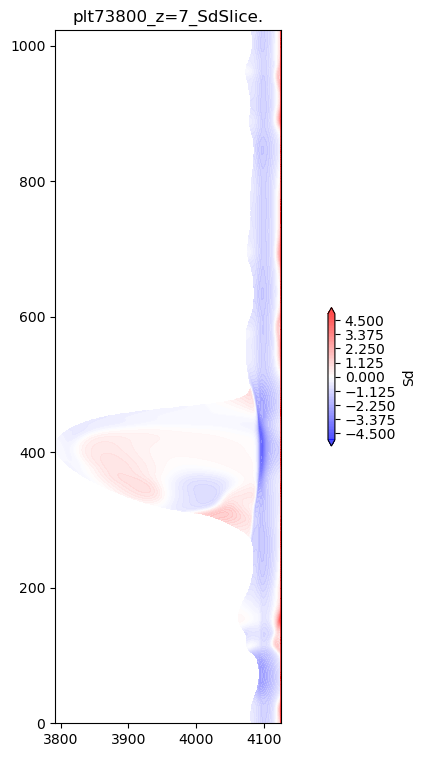

In [160]:
df['c'] = 1- df['Y(H2)']/0.012181
df1 = df[(df['z_grid'] ==7)]
df1 = df1[(df1['c']>=0.1)]
plot_general(df1,v='Sd',vmin=-5,vmax=5,fname='plt73800_z=7')

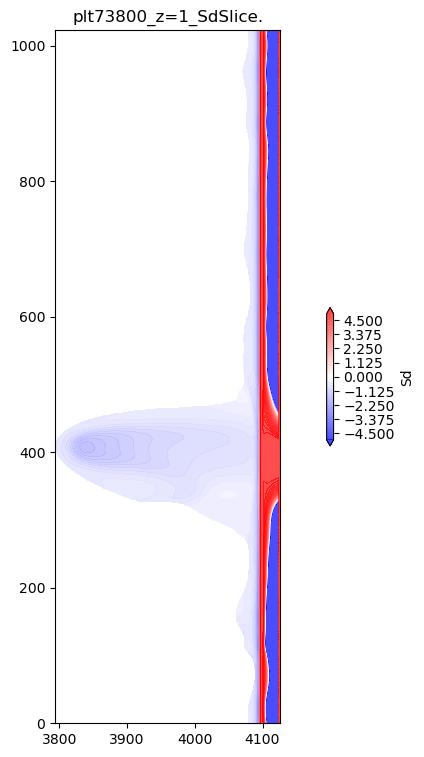